In [1]:
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np

import control

import archimedes as arc
from archimedes.experimental.approximation import Function, FunctionSpace

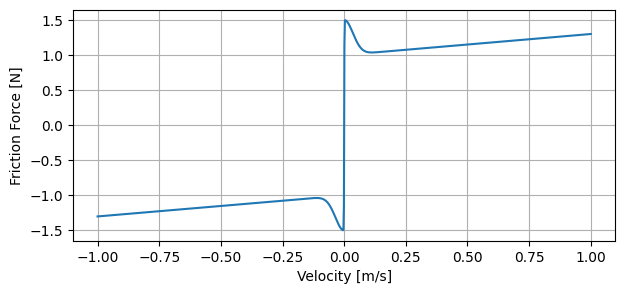

In [2]:
# Spring-mass-friction model

# Spring and mass parameters (assumed known/measurable)
m = 1.0  # mass [kg]
k = 25.0  # spring constant [N/m]

# True friction (assumed unknown, including model form)
@arc.struct
class FrictionForce:
    """Friction force model."""
    F_c: float  # Coulomb friction constant [N]
    F_s: float  # Static/stiction peak friction constant [N]
    v_s: float  # Stribeck velocity [m/s]
    F_v: float  # Viscous friction constant [N/(m/s)]
    v_eps: float  # Smoothing parameter for Coulomb friction [m/s]

    def __call__(self, v: float) -> float:
        """Compute the friction force for a given velocity."""
        return np.tanh(v / self.v_eps) * (
            self.F_c + (self.F_s - self.F_c)
            * np.exp(-(v / self.v_s) ** 2)
        ) + self.F_v * v


true_friction = FrictionForce(F_c=1.0, F_s=1.5, v_s=0.05, F_v=0.3, v_eps=1e-3)

v_plt = np.linspace(-1, 1, 1000)
f_plt = true_friction(v_plt)
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(v_plt, f_plt)
ax.set_xlabel('Velocity [m/s]')
ax.set_ylabel('Friction Force [N]')
ax.grid()
plt.show()

In [3]:
nx = 2  # Number of states (position, velocity)

def sys_rhs(t, y, u, friction=true_friction):
    x, v = y
    f = -friction(v) - k * x + u
    return np.hstack([v, f / m])

## Motion control with friction

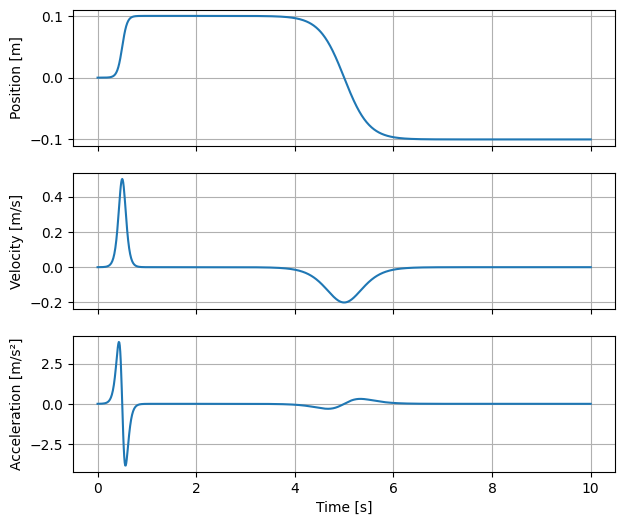

In [4]:
def sigmoid(t, t0=0.0, a=1.0):
    return 0.5 * (1 + np.tanh(a * (t - t0)))

def x_ref(t):
    x0 = 0.1
    return x0 * (sigmoid(t, t0=0.5, a=10.0) - 2 * sigmoid(t, t0=5.0, a=2.0))

v_ref = arc.grad(x_ref)
a_ref = arc.grad(v_ref)

t_ref = np.linspace(0, 10, 1000)

fig, ax = plt.subplots(3, 1, figsize=(7, 6), sharex=True)
ax[0].plot(t_ref, x_ref(t_ref))
ax[0].set_ylabel('Position [m]')
ax[0].grid()

ax[1].plot(t_ref, arc.vmap(v_ref)(t_ref))
ax[1].set_ylabel('Velocity [m/s]')
ax[1].grid()

ax[2].plot(t_ref, arc.vmap(a_ref)(t_ref))
ax[2].set_ylabel('Acceleration [m/s²]')
ax[2].grid()

ax[-1].set_xlabel('Time [s]')

plt.show()

We'll use an Internal Model Control structure, which in this case produces a filtered ideal PID law.  To focus on the effect of the friction nonlinearity, we'll simulate this as a continuous system (neglecting discretization) and assume the mass and spring constant are known exactly.

In [5]:
@arc.struct
class StateSpaceSystem:
    """Ideal filtered PID controller (continuous-time)"""
    A: np.ndarray
    B: np.ndarray
    C: np.ndarray
    D: np.ndarray

    def dynamics(self, t: float, x: np.ndarray, u: np.ndarray):
        u = np.atleast_1d(u)
        x_dot = self.A @ x + self.B @ u
        return x_dot.squeeze()

    def output(self, t: float, x: np.ndarray, u: np.ndarray):
        u = np.atleast_1d(u)
        y = self.C @ x + self.D @ u
        return y.squeeze()

    @property
    def nx(self):
        return self.A.shape[0]

    @classmethod
    def from_tf(cls, tf: control.TransferFunction):
        """Create a state-space system from a transfer function."""
        A, B, C, D = control.ssdata(tf)
        return cls(A=A, B=B, C=C, D=D)


In [6]:
# Internal model control gains
def imc_controller(m, b, k, lam):
    kp = b / (2 * lam)
    ki = k / (2 * lam)
    kd = m / (2 * lam)
    tau_f = lam / 2

    s = control.TransferFunction.s
    pid_tf = (kp + ki / s + kd * s) / (1 + tau_f * s)
    pid_tf = control.minreal(pid_tf, verbose=False)
    return StateSpaceSystem.from_tf(pid_tf)

Position tracking error (MAE): 0.0106 m


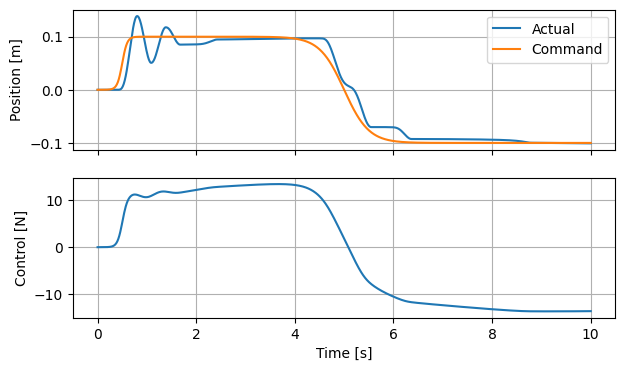

In [7]:
@arc.struct
class ClosedLoopSystem:
    """Closed-loop system with PID controller and spring-mass-friction dynamics."""
    controller: StateSpaceSystem
    ffwd: Callable = lambda t: 0.0  # Feedforward input (default: zero)

    def dynamics(self, t: float, y: np.ndarray):
        x = y[:nx]
        z = y[nx:]
        r = x_ref(t)
        e = r - x[0]
        z_dot = self.controller.dynamics(t, z, e)
        u_fb = self.controller.output(t, z, e)
        u_ff = self.ffwd(t)
        u = u_fb + u_ff
        x_dot = sys_rhs(t, x, u)
        return np.hstack([x_dot, z_dot])

    @property
    def nx(self):
        return nx + self.controller.nx


b = 20.0  # Approximate viscous damping coefficient [N/(m/s)]
pid = imc_controller(m=m, b=b, k=k, lam=0.1)
system = ClosedLoopSystem(controller=pid)

y0 = np.array([0.0, 0.0, 0.0, 0.0])
ys = arc.odeint(system.dynamics, [t_ref[0], t_ref[-1]], y0, t_eval=t_ref)
us = np.array([pid.output(t, y[nx:], x_ref(t)) for t, y in zip(t_ref, ys.T)])

# Mean tracking error
err = np.mean(np.abs(ys[0] - x_ref(t_ref)))
print(f"Position tracking error (MAE): {err:.4f} m")

fig, ax = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
ax[0].plot(t_ref, ys[0], label='Actual')
ax[0].plot(t_ref, x_ref(t_ref), label='Command')
ax[0].set_ylabel('Position [m]')
ax[0].grid()
ax[0].legend()

ax[1].plot(t_ref, us)
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Control [N]')
ax[1].grid()

ax[-1].set_xlabel('Time [s]')
plt.show()

## System ID

Text(0.5, 1.0, 'Chirp Force Input')

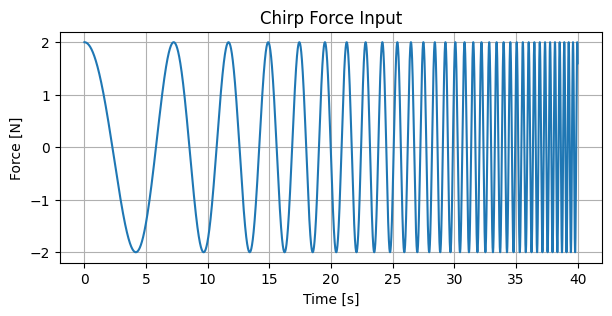

In [8]:
# Scipy chirp function for force

from scipy.signal import chirp

t0, tf = 0.0, 40.0
A = 2.0  # Forcing amplitude [N]
dt = 1e-3  # 1 kHz fine step for "truth"
tp = np.arange(t0, tf, dt)
u_chirp = A * chirp(tp, f0=0.1, f1=3.0, t1=tf, method='logarithmic')

fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(tp, u_chirp)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Force [N]')
ax.grid()
ax.set_title('Chirp Force Input')

Text(0.5, 1.0, 'Test Force Input (Multi-sine)')

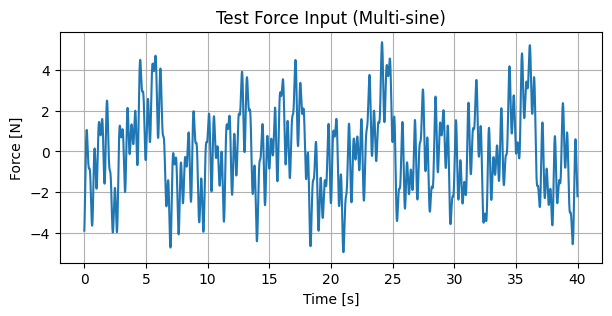

In [9]:
np.random.seed(42)
rng = np.random.default_rng(42)

freqs = np.logspace(np.log10(0.1), np.log10(3.0), 8)
phase = rng.uniform(0, 2 * np.pi, len(freqs))

u_test = np.sum(np.sin(2 * np.pi * freqs[:, None] * tp + phase[:, None]), axis=0)

fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(tp, u_test)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Force [N]')
ax.grid()
ax.set_title('Test Force Input (Multi-sine)')

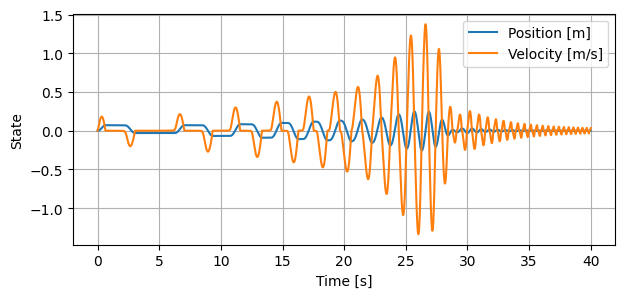

In [10]:
def chirp_rhs(t, y, friction):
    u = np.interp(t, tp, u_chirp)
    return sys_rhs(t, y, u)
    

y0 = np.array([0.0, 0.0])
ys = arc.odeint(chirp_rhs, [t0, tf], y0, t_eval=tp, args=(true_friction,))

fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(tp, ys[0], label='Position [m]')
ax.plot(tp, ys[1], label='Velocity [m/s]')
ax.set_xlabel('Time [s]')
ax.set_ylabel('State')
ax.grid()
ax.legend()
plt.show()

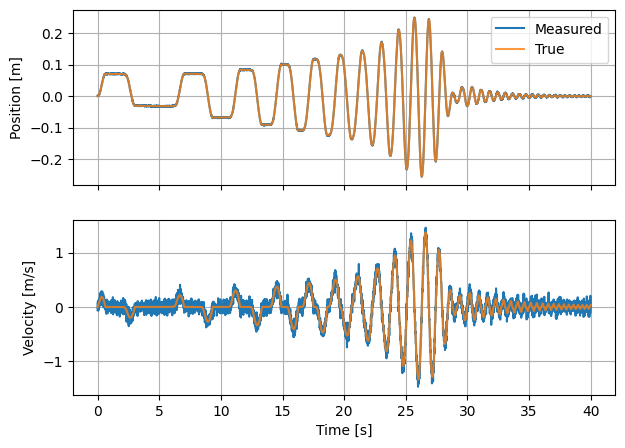

In [11]:
# Subsample to 100 Hz and add noise

ts = np.arange(t0, tf, 1e-2)
xs = np.interp(ts, tp, ys[0])
xs += 1e-3 * np.random.randn(len(xs))  # Add noise

data = arc.sysid.Timeseries(
    ts=ts,
    us=np.interp(ts, tp, u_chirp).reshape(1, -1),
    ys=xs.reshape(1, -1),
)

fig, ax = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
ax[0].plot(ts, xs, label="Measured")
ax[0].plot(tp, ys[0], alpha=0.8, label="True")
ax[0].set_ylabel('Position [m]')
ax[0].grid()
ax[0].legend()
vs_fd = np.gradient(xs, ts)
ax[1].plot(ts, vs_fd, label="Measured")
ax[1].plot(tp, ys[1], alpha=0.8, label="True")
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Velocity [m/s]')
ax[1].grid()
plt.show()

## System ID

In [ ]:

@arc.struct
class FrictionModel:
    """Friction model for system identification."""
    coeffs: np.ndarray
    space: FunctionSpace = arc.field(static=True)

    def __call__(self, v: float) -> float:
        """Compute the friction force for a given velocity."""
        f = self.space.function(self.coeffs)
        # FIXME: The function should handle scalars
        return f(np.atleast_1d(v)).squeeze()


# Cluster breakpoints near the origin to resolve the Stribeck effect
# bkpts = np.linspace(-1, 1, 10) ** 3
bkpts = np.linspace(-1, 1, 10)
# space = FunctionSpace.piecewise("hermite", degree=3, breakpoints=bkpts, continuity=1)
space = FunctionSpace.piecewise("lagrange", 1, bkpts)  # linear

dt = data.ts[1] - data.ts[0]

# Dynamics model (discretized with RK4)
@arc.discretize(dt=dt, method="rk4", n_steps=1)
def dyn(t, y, u, p):
    friction = FrictionModel(p, space)
    x, v = y
    f = -friction(v) - k * x + u
    return np.hstack([v, f / m])

# Observation model
def obs(t, y, u, p):
    return y[0]  # Observe position


nx, ny = 2, 1  # State and output dimensions

# Set up noise estimates
noise_var = 0.5 * np.var(np.diff(data.ys[0]))
R = noise_var * np.eye(ny)  # Measurement noise
Q = 1e-2 * noise_var * np.eye(nx)  # Process noise

# Extended Kalman Filter for predictions
ekf = arc.observers.ExtendedKalmanFilter(dyn, obs, Q, R)

# Estimate parameters
params_guess = np.zeros_like(space.function().coefficients)
P0 = 1e-3 * np.eye(nx)  # Initial state covariance
options = {
    "ftol": 1e-6,
    "xtol": 1e-6,
}
result = arc.sysid.pem(ekf, data, params_guess, x0=np.zeros(2), P0=P0, options=options)

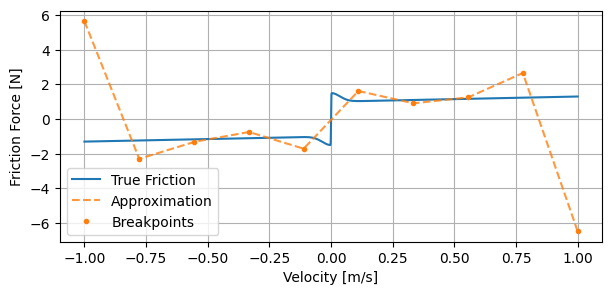

In [13]:
est_friction = space.function(result.p)

v_plt = np.linspace(-1, 1, 3000)
f_plt = true_friction(v_plt)
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(v_plt, f_plt, label="True Friction")
l, = ax.plot(v_plt, est_friction(v_plt), "--", alpha=0.8, label="Approximation")
ax.plot(bkpts, est_friction(bkpts), ".", color=l.get_color(), label="Breakpoints")
ax.legend()
ax.set_xlabel('Velocity [m/s]')
ax.set_ylabel('Friction Force [N]')
# ax.set_xlim([-0.1, 0.1])
ax.grid()
plt.show()

In [14]:
xs_pred = np.zeros((nx, len(data.ts)))
xs_pred[:, 0] = np.zeros(nx)  # Initial state guess
for i in range(1, len(data.ts)):
    t = data.ts[i - 1]
    u = data.us[:, i - 1]
    xs_pred[:, i] = dyn(t, xs_pred[:, i - 1], u, result.p)

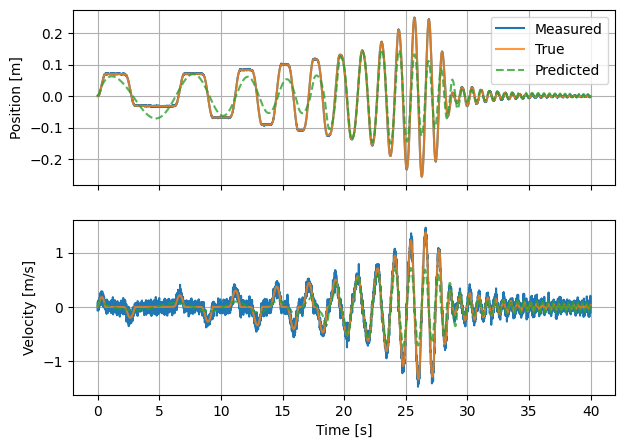

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
ax[0].plot(ts, xs, label="Measured")
ax[0].plot(tp, ys[0], alpha=0.8, label="True")
ax[0].plot(ts, xs_pred[0], "--", alpha=0.8, label="Predicted")
ax[0].set_ylabel('Position [m]')
ax[0].grid()
ax[0].legend()
vs_fd = np.gradient(xs, ts)
ax[1].plot(ts, vs_fd, label="Measured")
ax[1].plot(tp, ys[1], alpha=0.8, label="True")
ax[1].plot(ts, xs_pred[1], "--", alpha=0.8, label="Predicted")
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Velocity [m/s]')
ax[1].grid()
plt.show()

## Laguerre

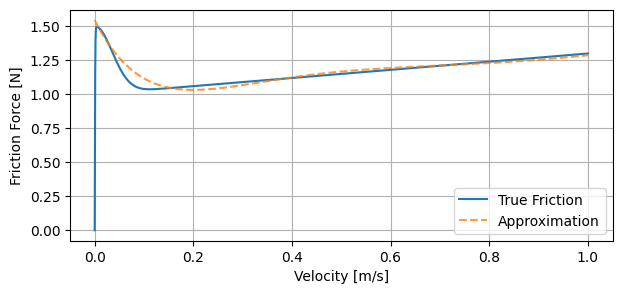

In [16]:
# Test projection of friction function onto a piecewise Hermite basis

from archimedes.experimental.approximation import FunctionSpace

# Cluster breakpoints near the origin to resolve the Stribeck effect
space = FunctionSpace.laguerre(n_basis=16, start=0.0, rate=3.0)
F_approx = space.project(true_friction)

v_plt = np.linspace(0, 1, 3000)
f_plt = true_friction(v_plt)
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(v_plt, f_plt, label="True Friction")
l, = ax.plot(v_plt, F_approx(v_plt), "--", alpha=0.8, label="Approximation")
ax.legend()
ax.set_xlabel('Velocity [m/s]')
ax.set_ylabel('Friction Force [N]')
# ax.set_xlim([0.0, 1.0])
ax.grid()
plt.show()

In [17]:
@arc.struct
class FrictionModel:
    """Friction model for system identification."""
    function: Function

    def __call__(self, v: float, eps: float = None) -> float:
        """Compute the friction force for a given velocity."""
        # FIXME: The function should handle scalars
        ff = self.function(abs(np.atleast_1d(v))).squeeze()
        if eps is None:
            return np.where(v >= 0, ff, -ff)
        return np.tanh(v / eps) * ff

In [18]:



space = FunctionSpace.laguerre(n_basis=10, rate=3.0)
dt = data.ts[1] - data.ts[0]

# Dynamics model (discretized with RK4)
@arc.discretize(dt=dt, method="rk4", n_steps=1)
def dyn(t, y, u, p):
    friction = FrictionModel(p)
    x, v = y
    f = -friction(v) - k * x + u
    return np.hstack([v, f / m])

# Observation model
def obs(t, y, u, p):
    return y[0]  # Observe position


nx, ny = 2, 1  # State and output dimensions

# Set up noise estimates
noise_var = 0.5 * np.var(np.diff(data.ys[0]))
R = noise_var * np.eye(ny)  # Measurement noise
Q = 1e-2 * noise_var * np.eye(nx)  # Process noise

# Extended Kalman Filter for predictions
ekf = arc.observers.ExtendedKalmanFilter(dyn, obs, Q, R)

# Estimate parameters
params_guess = space.function()
P0 = 1e-3 * np.eye(nx)  # Initial state covariance
options = {
    # "ftol": 1e-6,
    # "xtol": 1e-6,
}
result = arc.sysid.pem(ekf, data, params_guess, x0=np.zeros(2), P0=P0, options=options)

Iteration   Total nfev       Cost       Cost reduction   Step norm    Optimality 
    0           2         2.9747e-02                                   5.61e-01  
    1           4         1.7947e-02       1.18e-02       3.26e-01     3.09e-01  
    2           5         1.1165e-02       6.78e-03       1.08e-01     2.90e-01  
    3           6         7.5803e-03       3.58e-03       1.79e-01     1.56e-01  
    4           7         6.5076e-03       1.07e-03       7.40e-02     1.10e-01  
    5           8         5.8122e-03       6.95e-04       9.69e-02     1.06e-01  
    6           9         5.0356e-03       7.77e-04       1.65e-01     5.72e-02  
    7           10        4.3993e-03       6.36e-04       2.49e-01     5.00e-02  
    8           11        3.9339e-03       4.65e-04       3.88e-01     4.13e-02  
    9           12        3.8669e-03       6.70e-05       6.42e-01     4.48e-02  
    10          14        3.4401e-03       4.27e-04       1.30e-01     3.40e-02  
    11          

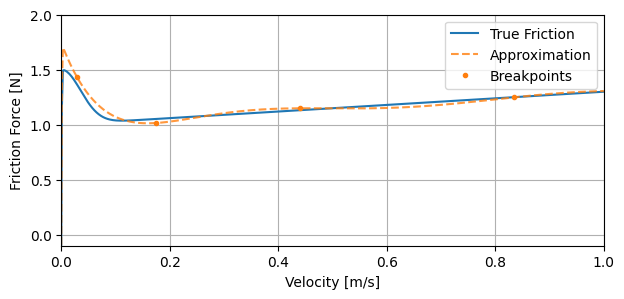

In [19]:
est_friction = FrictionModel(result.p)

nodes = result.p.space.basis_matrix().nodes

v_plt = np.linspace(-1, 1, 1000)
f_plt = true_friction(v_plt)
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(v_plt, f_plt, label="True Friction")
l, = ax.plot(v_plt, est_friction(v_plt, eps=1e-3), "--", alpha=0.8, label="Approximation")
ax.plot(nodes, est_friction(nodes), ".", color=l.get_color(), label="Breakpoints")
ax.legend()
ax.set_xlabel('Velocity [m/s]')
ax.set_ylabel('Friction Force [N]')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([-0.1, 2.0])
ax.grid()
plt.show()

In [20]:
xs_pred = np.zeros((nx, len(data.ts)))
xs_pred[:, 0] = np.zeros(nx)  # Initial state guess
for i in range(1, len(data.ts)):
    t = data.ts[i - 1]
    u = data.us[:, i - 1]
    xs_pred[:, i] = dyn(t, xs_pred[:, i - 1], u, result.p)

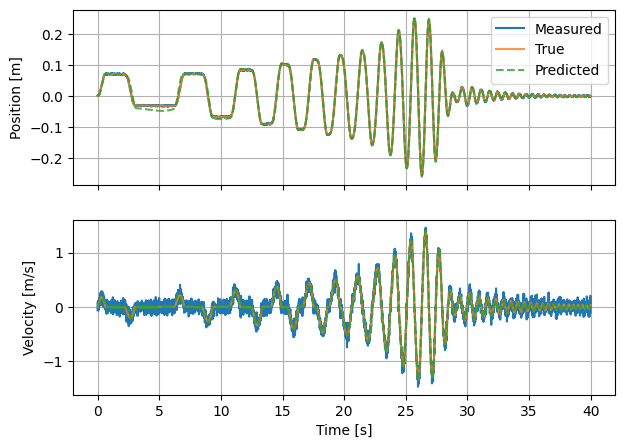

In [21]:
fig, ax = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
ax[0].plot(ts, xs, label="Measured")
ax[0].plot(tp, ys[0], alpha=0.8, label="True")
ax[0].plot(ts, xs_pred[0], "--", alpha=0.8, label="Predicted")
ax[0].set_ylabel('Position [m]')
ax[0].grid()
ax[0].legend()
vs_fd = np.gradient(xs, ts)
ax[1].plot(ts, vs_fd, label="Measured")
ax[1].plot(tp, ys[1], alpha=0.8, label="True")
ax[1].plot(ts, xs_pred[1], "--", alpha=0.8, label="Predicted")
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Velocity [m/s]')
ax[1].grid()
plt.show()

## Feedforward compensation

$$u(t) = \underbrace{m ~ \ddot{x}_{\text{ref}}(t) + k ~ x_{\text{ref}}(t) + \hat F\big(\dot{x}_{\text{ref}}(t)\big)}_{\text{feedforward}} + \underbrace{K_p ~ (x_{\text{ref}} - x) + K_i ~ \int_0^t (x_{\text{ref}} - x) ~ dt + K_d ~ (v_{\text{ref}} - v)}_{\text{PID feedback}}$$

Position tracking error (MAE): 0.0017 m


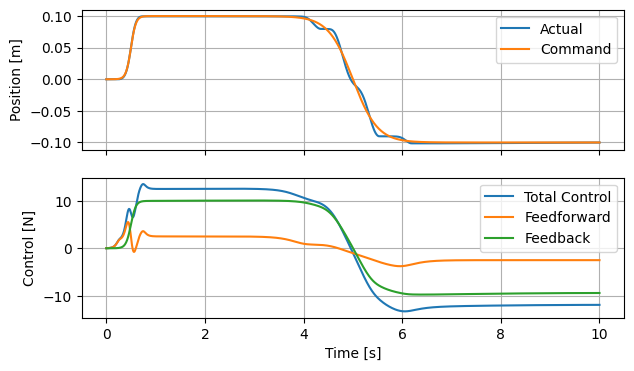

In [22]:
# Feedforward commands

def ffwd_ctrl(t):
    ff_est = est_friction(v_ref(t), eps=1e-2)
    # ff_est = true_friction(v_ref(t))
    return m * a_ref(t) + k * x_ref(t) + ff_est


# Reuse the same PID controller, just add feedforward
system = ClosedLoopSystem(controller=pid, ffwd=ffwd_ctrl)

y0 = np.zeros(system.nx)
t0, tf = t_ref[0], t_ref[-1]
dt = t_ref[1] - t_ref[0]
ys = arc.odeint(system.dynamics, [t0, tf], y0, t_eval=t_ref)
us_ff = arc.vmap(ffwd_ctrl)(t_ref)
us_fb = np.array([pid.output(t, y[nx:], x_ref(t)) for t, y in zip(t_ref, ys.T)])

# Mean tracking error
err = np.mean(np.abs(ys[0] - x_ref(t_ref)))
print(f"Position tracking error (MAE): {err:.4f} m")

fig, ax = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
ax[0].plot(t_ref, ys[0], label='Actual')
ax[0].plot(t_ref, x_ref(t_ref), label='Command')
ax[0].set_ylabel('Position [m]')
ax[0].grid()
ax[0].legend()

ax[1].plot(t_ref, us_ff + us_fb, label='Total Control')
ax[1].plot(t_ref, us_ff, label='Feedforward')
ax[1].plot(t_ref, us_fb, label='Feedback')
ax[1].legend()
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Control [N]')
ax[1].grid()

ax[-1].set_xlabel('Time [s]')
plt.show()